# **1. DATA COLLECTION**

In [19]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib

In [20]:
DATA_PATH = "/kaggle/input/smoking-disease-risk-dataset/brfss2020.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "/mnt/data/brfss2020.csv"

df = pd.read_csv(DATA_PATH)

print("DATA SHAPE:", df.shape)
df.head()


DATA SHAPE: (401958, 279)


,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_RFPSA23,_CLNSCPY,_SGMSCPY,_SGMS10Y,_RFBLDS4,_STOLDNA,_VIRCOLN,_SBONTIM,_CRCREC1,_AIDTST4
0,1.0,1.0,1042020,1,4,2020,1100.0,2020000001,2.020000e+09,1.0,...,NaN,1.0,3.0,3.0,3.0,3.0,3.0,3.0,1.0,1.0
1,1.0,1.0,2072020,2,7,2020,1200.0,2020000002,2.020000e+09,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
2,1.0,1.0,1232020,1,23,2020,1100.0,2020000003,2.020000e+09,1.0,...,NaN,1.0,3.0,3.0,3.0,3.0,3.0,3.0,1.0,2.0
3,1.0,1.0,1092020,1,9,2020,1100.0,2020000004,2.020000e+09,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
4,1.0,1.0,1042020,1,4,2020,1100.0,2020000005,2.020000e+09,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0


In [21]:
FEATURE_COLS = [
    # SMOKING + VAPING
    "SMOKE100",   # SMOKED 100+ CIGARETTES IN LIFETIME
    "SMOKDAY2",   # CURRENT SMOKING FREQUENCY
    "_SMOKER3",   # CDC SMOKER CATEGORY
    "ECIGARET",   # EVER USED E-CIG
    "ECIGNOW",    # CURRENT E-CIG USE

    # HEALTH
    "DIABETE4",   # DIABETES STATUS
    "PREDIAB1",   # PREDIABETES STATUS

    # NEW: DEMOGRAPHICS
    "_AGEG5YR",   # AGE GROUP (CDC CALCULATED AGE GROUP)
    "SEXVAR",     # SEX CATEGORY
    "_BMI5CAT"    # WEIGHT CATEGORY (UNDER/NORMAL/OVERWEIGHT/OBESE)
]

TARGET_COL = "_RFSMOK3"  # CDC CALCULATED SMOKER FLAG

missing = [c for c in FEATURE_COLS + [TARGET_COL] if c not in df.columns]
if missing:
    raise ValueError(f"THE FOLLOWING REQUIRED COLUMNS ARE MISSING: {missing}")

df_ml = df[FEATURE_COLS + [TARGET_COL]].copy()
df_ml.head()


,SMOKE100,SMOKDAY2,_SMOKER3,ECIGARET,ECIGNOW,DIABETE4,PREDIAB1,_AGEG5YR,SEXVAR,_BMI5CAT,_RFSMOK3
0,1.0,1.0,1.0,1.0,3.0,1.0,NaN,8.0,2.0,1.0,2.0
1,NaN,NaN,9.0,NaN,NaN,3.0,1.0,10.0,2.0,3.0,9.0
2,2.0,NaN,4.0,2.0,NaN,3.0,3.0,10.0,2.0,NaN,1.0
3,2.0,NaN,4.0,2.0,NaN,3.0,3.0,13.0,2.0,NaN,1.0
4,2.0,NaN,4.0,2.0,NaN,3.0,3.0,13.0,2.0,2.0,1.0


# **2. DATA CLEANING**

In [22]:
df_ml = df_ml[df_ml[TARGET_COL].isin([1, 2])].copy()
df_ml["HIGH_RISK"] = (df_ml[TARGET_COL] == 2).astype(int)
df_ml.drop(columns=[TARGET_COL], inplace=True)

print(df_ml["HIGH_RISK"].value_counts())
df_ml.head()

HIGH_RISK
0    328370
1     52488
Name: count, dtype: int64


,SMOKE100,SMOKDAY2,_SMOKER3,ECIGARET,ECIGNOW,DIABETE4,PREDIAB1,_AGEG5YR,SEXVAR,_BMI5CAT,HIGH_RISK
0,1.0,1.0,1.0,1.0,3.0,1.0,NaN,8.0,2.0,1.0,1
2,2.0,NaN,4.0,2.0,NaN,3.0,3.0,10.0,2.0,NaN,0
3,2.0,NaN,4.0,2.0,NaN,3.0,3.0,13.0,2.0,NaN,0
4,2.0,NaN,4.0,2.0,NaN,3.0,3.0,13.0,2.0,2.0,0
5,1.0,3.0,3.0,1.0,3.0,1.0,NaN,10.0,1.0,3.0,0


In [23]:
INVALID_CODES = {7: np.nan, 9: np.nan, 77: np.nan, 99: np.nan, 88: np.nan}

for col in FEATURE_COLS:
    if df_ml[col].dtype != "object":
        df_ml[col] = df_ml[col].replace(INVALID_CODES)

print("MISSING VALUES PER COLUMN:")
print(df_ml[FEATURE_COLS].isna().sum().sort_values(ascending=False))

MISSING VALUES PER COLUMN:
ECIGNOW     330467
SMOKDAY2    224535
PREDIAB1    173027
ECIGARET    118599
_AGEG5YR     68638
_BMI5CAT     28195
DIABETE4       653
SMOKE100         0
_SMOKER3         0
SEXVAR           0
dtype: int64


In [24]:
print("DUPLICATES:", df_ml.duplicated().sum())
print("\nDATA TYPES:\n", df_ml.dtypes)

df_ml.describe(include="all")

DUPLICATES: 370319

DATA TYPES:
 SMOKE100     float64
SMOKDAY2     float64
_SMOKER3     float64
ECIGARET     float64
ECIGNOW      float64
DIABETE4     float64
PREDIAB1     float64
_AGEG5YR     float64
SEXVAR       float64
_BMI5CAT     float64
HIGH_RISK      int64
dtype: object


,SMOKE100,SMOKDAY2,_SMOKER3,ECIGARET,ECIGNOW,DIABETE4,PREDIAB1,_AGEG5YR,SEXVAR,_BMI5CAT,HIGH_RISK
count,380858.000000,156323.000000,380858.000000,262259.000000,50391.000000,380205.000000,207831.000000,312220.000000,380858.000000,352663.000000,380858.000000
mean,1.589550,2.420175,3.351561,1.807316,2.719732,2.752155,2.726316,7.558388,1.542816,2.983049,0.137815
std,0.491916,0.855424,0.950944,0.394407,0.610726,0.700693,0.678988,3.994527,0.498164,0.831907,0.344706
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,4.000000,1.000000,2.000000,0.000000
50%,2.000000,3.000000,4.000000,2.000000,3.000000,3.000000,3.000000,8.000000,2.000000,3.000000,0.000000
75%,2.000000,3.000000,4.000000,2.000000,3.000000,3.000000,3.000000,11.000000,2.000000,4.000000,0.000000
max,2.000000,3.000000,4.000000,2.000000,3.000000,4.000000,3.000000,14.000000,2.000000,4.000000,1.000000


# **3. DATA ANALYSIS**

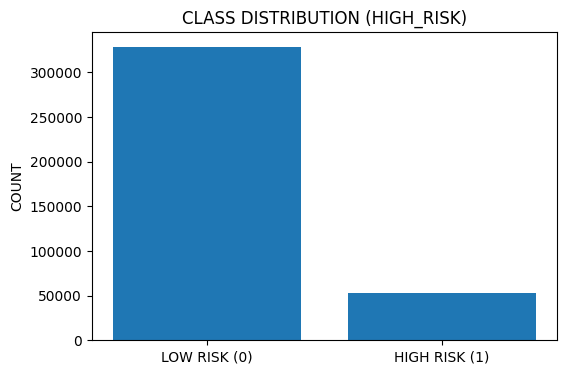

CLASS DISTRIBUTION:
 HIGH_RISK
0    328370
1     52488
Name: count, dtype: int64

HIGH RISK RATE: 13.78 %


In [25]:
counts = df_ml["HIGH_RISK"].value_counts().sort_index()
labels = ["LOW RISK (0)", "HIGH RISK (1)"]

plt.figure(figsize=(6,4))
plt.bar(labels, counts.values)
plt.title("CLASS DISTRIBUTION (HIGH_RISK)")
plt.ylabel("COUNT")
plt.show()

print("CLASS DISTRIBUTION:\n", counts)
print("\nHIGH RISK RATE:", round(counts.get(1,0) / counts.sum() * 100, 2), "%")

In [26]:
for col in FEATURE_COLS:
    print("\n" + "="*60)
    print(f"{col} VALUE COUNTS (TOP 10)")
    print(df_ml[col].value_counts(dropna=False).head(10))


SMOKE100 VALUE COUNTS (TOP 10)
SMOKE100
2.0    224535
1.0    156323
Name: count, dtype: int64

SMOKDAY2 VALUE COUNTS (TOP 10)
SMOKDAY2
NaN    224535
3.0    103835
1.0     38152
2.0     14336
Name: count, dtype: int64

_SMOKER3 VALUE COUNTS (TOP 10)
_SMOKER3
4.0    224535
3.0    103835
1.0     38152
2.0     14336
Name: count, dtype: int64

ECIGARET VALUE COUNTS (TOP 10)
ECIGARET
2.0    211726
NaN    118599
1.0     50533
Name: count, dtype: int64

ECIGNOW VALUE COUNTS (TOP 10)
ECIGNOW
NaN    330467
3.0     40583
2.0      5493
1.0      4315
Name: count, dtype: int64

DIABETE4 VALUE COUNTS (TOP 10)
DIABETE4
3.0    319107
1.0     49642
4.0      8254
2.0      3202
NaN       653
Name: count, dtype: int64

PREDIAB1 VALUE COUNTS (TOP 10)
PREDIAB1
3.0    178202
NaN    173027
1.0     27251
2.0      2378
Name: count, dtype: int64

_AGEG5YR VALUE COUNTS (TOP 10)
_AGEG5YR
NaN     68638
10.0    39769
11.0    36387
8.0     34455
13.0    29855
12.0    25426
6.0     25076
1.0     24313
5.0     24295
4.

# **4. MODEL TRAINING**

In [27]:
X = df_ml[FEATURE_COLS].copy()
y = df_ml["HIGH_RISK"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("TRAIN SHAPE:", X_train.shape, "TEST SHAPE:", X_test.shape)
print("TRAIN CLASS BALANCE:\n", y_train.value_counts(normalize=True))
print("TEST CLASS BALANCE:\n", y_test.value_counts(normalize=True))

TRAIN SHAPE: (304686, 10) TEST SHAPE: (76172, 10)
TRAIN CLASS BALANCE:
 HIGH_RISK
0    0.862186
1    0.137814
Name: proportion, dtype: float64
TEST CLASS BALANCE:
 HIGH_RISK
0    0.86218
1    0.13782
Name: proportion, dtype: float64


In [28]:
categorical_features = FEATURE_COLS

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [29]:
log_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=None))
])

rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

print("PIPELINES READY.")

PIPELINES READY.


In [30]:
log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("MODELS TRAINED.")

KeyboardInterrupt: 

# **5. MODEL TESTING & EVALUATION**

In [ ]:
def evaluate_model(model, X_test, y_test, name="MODEL"):
    y_pred = model.predict(X_test)

    # PROBABILITIES FOR ROC-AUC (IF AVAILABLE)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        auc = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("\n" + "="*70)
    print(f"{name} RESULTS")
    print("="*70)
    print(f"ACCURACY : {acc:.4f}")
    print(f"PRECISION: {prec:.4f}")
    print(f"RECALL   : {rec:.4f}")
    print(f"F1-SCORE : {f1:.4f}")
    if auc is not None:
        print(f"ROC-AUC  : {auc:.4f}")

    print("\nCONFUSION MATRIX:")
    print(confusion_matrix(y_test, y_pred))

    print("\nCLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred, digits=4))

    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc, "proba": y_proba}


In [ ]:
res_lr = evaluate_model(log_reg, X_test, y_test, name="LOGISTIC REGRESSION")
res_rf = evaluate_model(rf, X_test, y_test, name="RANDOM FOREST")

In [ ]:
results_df = pd.DataFrame([
    {k: v for k, v in res_lr.items() if k != "proba"},
    {k: v for k, v in res_rf.items() if k != "proba"},
])

results_df

In [ ]:
plt.figure(figsize=(6,5))

if res_lr["proba"] is not None:
    RocCurveDisplay.from_predictions(y_test, res_lr["proba"], name="Logistic Regression")

if res_rf["proba"] is not None:
    RocCurveDisplay.from_predictions(y_test, res_rf["proba"], name="Random Forest")

plt.title("ROC CURVE COMPARISON")
plt.show()

In [ ]:
def pick_best_model(res_a, model_a, res_b, model_b):
    # PREFER ROC-AUC IF AVAILABLE
    if res_a["roc_auc"] is not None and res_b["roc_auc"] is not None:
        return (model_a, res_a) if res_a["roc_auc"] >= res_b["roc_auc"] else (model_b, res_b)
    # FALLBACK TO F1
    return (model_a, res_a) if res_a["f1"] >= res_b["f1"] else (model_b, res_b)

best_model, best_res = pick_best_model(res_lr, log_reg, res_rf, rf)
print("BEST MODEL:", best_res["name"])

joblib.dump(best_model, "best_smoking_risk_model.joblib")
print("SAVED AS: best_smoking_risk_model.joblib")

# **6. GRADIO APPLICATION**

In [31]:
import gradio as gr
import joblib
import pandas as pd

# LOAD TRAINED MODEL (YOU SAVED THIS FROM YOUR NOTEBOOK)
model = joblib.load("best_smoking_risk_model.joblib")

# -------------------------
# WORD LABELS -> BRFSS CODE MAPS
# -------------------------

SMOKE100_MAP = {"Yes": 1, "No": 2}

SMOKDAY2_MAP = {"Every day": 1, "Some days": 2, "Not at all": 3}

SMOKER3_MAP = {
    "Current smoker (every day)": 1,
    "Current smoker (some days)": 2,
    "Former smoker": 3,
    "Never smoked": 4
}

ECIGARET_MAP = {"Yes": 1, "No": 2}

ECIGNOW_MAP = {
    "Every day": 1,
    "Some days": 2,
    "Not at all": 3,
    "Rarely": 4
}

DIABETE4_MAP = {
    "Yes (diagnosed diabetes)": 1,
    "Yes (only during pregnancy)": 2,
    "No": 3,
    "Prediabetes / borderline": 4
}

PREDIAB1_MAP = {"Yes": 1, "No": 2}

# DEMOGRAPHICS MAPS
AGE_MAP = {
    "18–24": 1, "25–29": 2, "30–34": 3, "35–39": 4, "40–44": 5, "45–49": 6,
    "50–54": 7, "55–59": 8, "60–64": 9, "65–69": 10, "70–74": 11, "75–79": 12, "80+": 13
}

SEX_MAP = {"Male": 1, "Female": 2}

BMI_MAP = {
    "Underweight": 1,
    "Normal weight": 2,
    "Overweight": 3,
    "Obese": 4
}

# EDUCATIONAL DISEASE LIST (NOT A DIAGNOSIS)
POSSIBLE_DISEASES = [
    "Heart disease and heart attack",
    "Stroke",
    "Chronic obstructive pulmonary disease (COPD)",
    "Lung cancer and other smoking-related cancers",
    "High blood pressure and blood vessel disease",
    "Worsening diabetes complications",
    "Reduced lung function and respiratory infections"
]


def predict_overall_health_risk(
    age_group, sex, weight_category,
    smoke100, smokday2, smoker3,
    ecigaret, ecignow,
    diabete4, prediab1
):
    # BUILD INPUT (WORDS -> BRFSS CODES)
    X_input = pd.DataFrame([{
        "_AGEG5YR": AGE_MAP[age_group],
        "SEXVAR": SEX_MAP[sex],
        "_BMI5CAT": BMI_MAP[weight_category],

        "SMOKE100": SMOKE100_MAP[smoke100],
        "SMOKDAY2": SMOKDAY2_MAP[smokday2],
        "_SMOKER3": SMOKER3_MAP[smoker3],
        "ECIGARET": ECIGARET_MAP[ecigaret],
        "ECIGNOW": ECIGNOW_MAP[ecignow],
        "DIABETE4": DIABETE4_MAP[diabete4],
        "PREDIAB1": PREDIAB1_MAP[prediab1]
    }])

    # BASE ML PROBABILITY
    base_proba = float(model.predict_proba(X_input)[0, 1])

    # -------------------------
    # SIMPLE ADJUSTMENTS (OPTIONAL, ENTRY-LEVEL)
    # -------------------------
    vape_adjust = 0.0
    if ecignow == "Every day":
        vape_adjust = 0.10
    elif ecignow == "Some days":
        vape_adjust = 0.05

    age_adjust = 0.0
    if age_group in ["65–69", "70–74", "75–79", "80+"]:
        age_adjust = 0.08
    elif age_group in ["55–59", "60–64"]:
        age_adjust = 0.05
    elif age_group in ["45–49", "50–54"]:
        age_adjust = 0.03

    bmi_adjust = 0.0
    if weight_category == "Obese":
        bmi_adjust = 0.05
    elif weight_category == "Overweight":
        bmi_adjust = 0.03
    elif weight_category == "Underweight":
        bmi_adjust = 0.02

    final_risk = min(max(base_proba + vape_adjust + age_adjust + bmi_adjust, 0.0), 1.0)

    # RISK BANDS
    if final_risk >= 0.70:
        band = "HIGH RISK"
        action = "Strongly recommended to stop smoking/vaping and consider a medical check-up."
    elif final_risk >= 0.40:
        band = "MODERATE RISK"
        action = "Recommended to reduce or quit smoking/vaping and monitor your health."
    else:
        band = "LOWER RISK"
        action = "Risk appears lower, but quitting smoking/vaping is still recommended for long-term health."

    diseases_md = "\n".join([f"- {d}" for d in POSSIBLE_DISEASES])

    output_md = f"""
# Health Risk Result

## Estimated Overall Health Risk
### **{final_risk:.1%}**

## Risk Level
### **{band}**

## Recommendation
{action}

---

## Possible health conditions linked to smoking and vaping (educational)
{diseases_md}

---

### Disclaimer
This tool is for educational purposes only and does not provide medical diagnosis.
Please consult a healthcare professional for medical advice.
"""
    return output_md


with gr.Blocks(title="Smoking & Vaping Health Risk Classifier") as demo:

    gr.Markdown(
        """
        # Smoking & Vaping Health Risk Classifier (BRFSS 2020)

        This entry-level system provides an **overall health risk estimate** based on:
        - Demographics (age, sex, weight category)
        - Cigarette smoking behaviour
        - Vaping behaviour
        - Diabetes indicators
        """
    )

    # NEW: MODEL INFORMATION SECTION
    gr.Markdown(
        """
        ## Model Information

        **Baseline Model:** Logistic Regression  
        **Final Deployed Model:** Random Forest Classifier  

        **Dataset:** CDC BRFSS 2020 Public Health Survey  
        **Task:** Binary Classification (Overall High Risk vs Lower Risk)
        """
    )

    # DEMOGRAPHICS ROW
    with gr.Row():
        with gr.Column():
            age_group = gr.Dropdown(list(AGE_MAP.keys()), value="25–29", label="Age group")
        with gr.Column():
            sex = gr.Radio(list(SEX_MAP.keys()), value="Female", label="Sex")
        with gr.Column():
            weight_category = gr.Dropdown(list(BMI_MAP.keys()), value="Normal weight", label="Weight category")

    # MAIN INPUTS ROW (3 COLUMNS)
    with gr.Row():
        # CIGARETTE COLUMN
        with gr.Column():
            gr.Markdown("## 🚬 Cigarette Smoking")
            smoke100 = gr.Dropdown(list(SMOKE100_MAP.keys()), label="Smoked 100+ cigarettes in lifetime?")
            smokday2 = gr.Dropdown(list(SMOKDAY2_MAP.keys()), label="How often do you currently smoke?")
            smoker3 = gr.Dropdown(list(SMOKER3_MAP.keys()), label="Smoking status category")

        # VAPE COLUMN
        with gr.Column():
            gr.Markdown("## 💨 Vaping")
            ecigaret = gr.Dropdown(list(ECIGARET_MAP.keys()), label="Ever used e-cigarettes (vapes)?")
            ecignow = gr.Dropdown(list(ECIGNOW_MAP.keys()), label="Do you currently use e-cigarettes?")

        # HEALTH COLUMN
        with gr.Column():
            gr.Markdown("## 🩺 Health Conditions")
            diabete4 = gr.Dropdown(list(DIABETE4_MAP.keys()), label="Diabetes status")
            prediab1 = gr.Dropdown(list(PREDIAB1_MAP.keys()), label="Prediabetes status")

    predict_btn = gr.Button("Check My Health Risk")
    output = gr.Markdown()

    predict_btn.click(
        fn=predict_overall_health_risk,
        inputs=[
            age_group, sex, weight_category,
            smoke100, smokday2, smoker3,
            ecigaret, ecignow,
            diabete4, prediab1
        ],
        outputs=output
    )

demo.launch(debug=False)

* Running on local URL:  http://127.0.0.1:7861
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://beaccb26ba7a1cf481.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
